In [176]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from kmodes.kprototypes import KPrototypes
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import plotly.express as px
import gower
import hdbscan
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os

In [177]:

purchases = pd.read_csv("../analisis exploratorio/amazon-purchases.csv")
survey = pd.read_csv("../analisis exploratorio/survey2.csv")

In [178]:
purchases.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Order Date                1850717 non-null  object 
 1   Purchase Price Per Unit   1850717 non-null  float64
 2   Quantity                  1850717 non-null  float64
 3   Shipping Address State    1762905 non-null  object 
 4   Title                     1760977 non-null  object 
 5   ASIN/ISBN (Product Code)  1849744 non-null  object 
 6   Category                  1761259 non-null  object 
 7   Survey ResponseID         1850717 non-null  object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


## Filtro de Base de datos de compras de samsung

In [179]:
purchases_samsung = purchases[
    purchases["Title"].str.contains(r"\bsamsung\b", case=False, regex=True, na=False)
].copy()

purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19706 entries, 5 to 1850564
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                19706 non-null  object 
 1   Purchase Price Per Unit   19706 non-null  float64
 2   Quantity                  19706 non-null  float64
 3   Shipping Address State    19136 non-null  object 
 4   Title                     19706 non-null  object 
 5   ASIN/ISBN (Product Code)  19704 non-null  object 
 6   Category                  19699 non-null  object 
 7   Survey ResponseID         19706 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.4+ MB


## Deteccion de duplicados de purchases_samsung

In [180]:
cant_duplicados =purchases_samsung.duplicated().sum()
cant_duplicados

25

In [181]:
num_datos = len(purchases_samsung)
print(f"Cantidad de compras de Samsung: {num_datos}")
print(f"Porcentaje de compras de Samsung duplicadas: {(cant_duplicados/num_datos)*100:.6f}%")

Cantidad de compras de Samsung: 19706
Porcentaje de compras de Samsung duplicadas: 0.126865%


## Eliminacion de duplicados

## Deteccion de nulos de base de datos samsung

In [182]:
os.makedirs("fig", exist_ok=True)

def grafico_faltantes_original(df, titulo, archivo, figsize=(14, 8)):
    missing_matrix = df.isnull()

    patrones = (
        missing_matrix.groupby(list(missing_matrix.columns))
        .size()
        .reset_index(name="Frecuencia_Filas")
    )

    patrones["Total_Faltantes_Por_Patron"] = patrones[df.columns].sum(axis=1)

    patrones = patrones.sort_values(
        by=["Total_Faltantes_Por_Patron", "Frecuencia_Filas"],
        ascending=[True, False],
    )

    total_faltantes_columna = missing_matrix.sum().sort_values()
    columnas_ordenadas = total_faltantes_columna.index

    matriz_plot = patrones[columnas_ordenadas].copy()
    conteos_filas = patrones["Frecuencia_Filas"].values
    conteos_cols_patron = patrones["Total_Faltantes_Por_Patron"].values
    conteos_totales_cols = total_faltantes_columna.values

    fig, ax = plt.subplots(figsize=figsize)

    cmap = sns.color_palette(["#4682B4", "#D16587"])

    sns.heatmap(
        matriz_plot,
        cmap=cmap,
        cbar=False,
        linewidths=0.5,
        linecolor="black",
        ax=ax,
        yticklabels=False,
    )

    ax.xaxis.tick_top()
    ax.set_xticklabels(columnas_ordenadas, rotation=90, fontsize=9)

    for i, count in enumerate(conteos_filas):
        ax.text(-0.5, i + 0.5, str(count), va="center", ha="right", fontsize=10)

    for i, count in enumerate(conteos_cols_patron):
        ax.text(
            len(columnas_ordenadas) + 0.5,
            i + 0.5,
            str(count),
            va="center",
            ha="left",
            fontsize=10,
        )

    for j, count in enumerate(conteos_totales_cols):
        ax.text(
            j + 0.5,
            len(patrones) + 0.5,
            str(count),
            va="top",
            ha="center",
            fontsize=10,
        )

    plt.title(titulo, y=-0.15, fontsize=12)

    plt.tight_layout()
    plt.savefig(f"fig/{archivo}", dpi=300, bbox_inches="tight")
    plt.show()

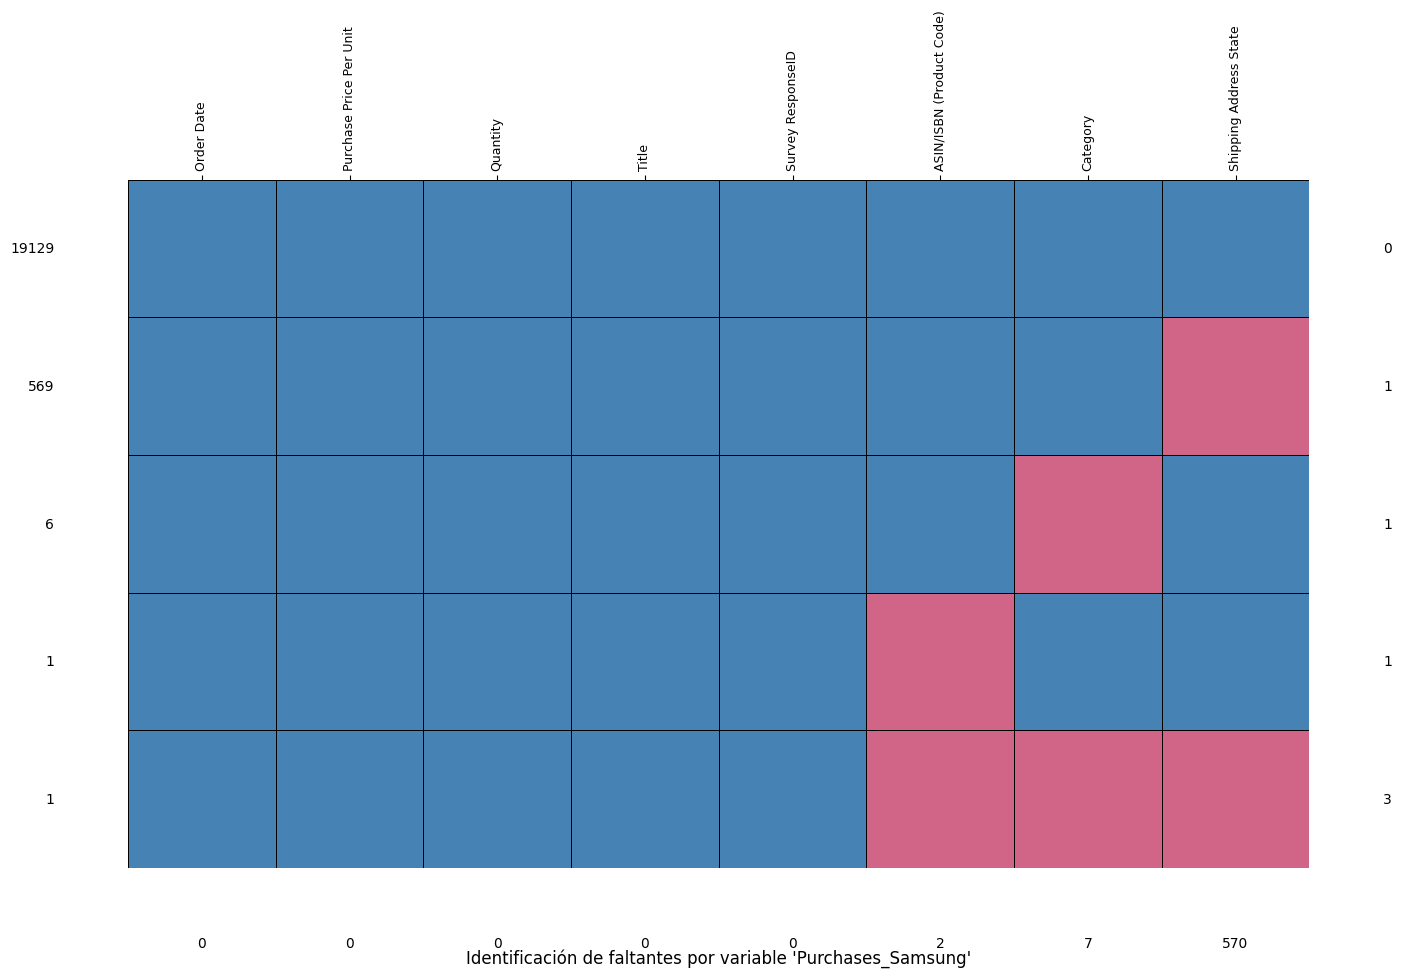

In [183]:


grafico_faltantes_original(
    purchases_samsung,
    "Identificación de faltantes por variable 'Purchases_Samsung'",
    "figura_1.png",
    figsize=(14, 10)
)

In [184]:
purchases_samsung.isnull().sum()

Order Date                    0
Purchase Price Per Unit       0
Quantity                      0
Shipping Address State      570
Title                         0
ASIN/ISBN (Product Code)      2
Category                      7
Survey ResponseID             0
dtype: int64

## ¿Cuanto se elimino de gasto?

In [185]:
purchases_samsung["amount"] = (
    purchases_samsung["Purchase Price Per Unit"] * purchases_samsung["Quantity"]
)

In [186]:
datos_nulos = purchases_samsung[
    purchases_samsung.isnull().any(axis=1)
].copy()

datos_nulos

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,amount
4782,2022-10-04,19.88,1.0,NaN,"Super Fast Charger Type C, 25W USB C Wall Char...",B09W2SPRDG,WIRELESS_ACCESSORY,R_0D6LkYgiPcEN117,19.88
15024,2018-05-22,39.99,1.0,NaN,SAMSUNG (MB-ME128GA/AM) 128GB 100MB/s (U3) Mic...,B06XWZWYVP,FLASH_MEMORY,R_0lHgeveolyaJhND,39.99
15056,2018-08-12,17.65,1.0,NaN,Samsung EF-RN950CBEGUS Galaxy Note8 Rugged Mil...,B074GB5QST,CELLULAR_PHONE_CASE,R_0lHgeveolyaJhND,17.65
15167,2019-11-01,7.85,1.0,NaN,IQShield Screen Protector Compatible with Sams...,B0787FWS72,SCREEN_PROTECTOR,R_0lHgeveolyaJhND,7.85
15194,2019-12-25,27.99,1.0,NaN,"Upgraded, Anker Soundcore Bluetooth Speaker wi...",B016XTADG2,SPEAKERS,R_0lHgeveolyaJhND,27.99
...,...,...,...,...,...,...,...,...,...
1782711,2022-09-22,12.99,1.0,NaN,Earbuds Headphones Wired Stereo Noise Earphone...,B0B368GCB7,HEADPHONES,R_tY9q5vSaULImPzb,12.99
1782713,2022-10-08,60.97,1.0,NaN,"SAMSUNG Electronics Wireless Charger Trio, Qi ...",B08FBFJDQ1,CHARGING_ADAPTER,R_tY9q5vSaULImPzb,60.97
1824687,2018-08-05,7.99,1.0,NaN,"Micro USB Cable,[2 Pack/3.3ft],Rampow QC 3.0 F...",B01GJC4WRO,ELECTRONIC_CABLE,R_xt1sEBScdPLKPhT,7.99
1833513,2020-07-26,49.99,1.0,NaN,Samsung SSD 860 EVO 250GB 2.5 Inch SATA III In...,B07864WMK8,COMPUTER_DRIVE_OR_STORAGE,R_yK4rOrk16ZOoWwp,49.99


In [187]:
amount_total_nulos = datos_nulos["amount"].sum()

amount_total_nulos

27924.14

In [188]:
print(f"Amount total de filas con algún dato nulo: {amount_total_nulos:,.2f}")

Amount total de filas con algún dato nulo: 27,924.14


In [189]:
# Crear amount si no existe
if "amount" not in purchases_samsung.columns:
    purchases_samsung["amount"] = (
        purchases_samsung["Purchase Price Per Unit"] * purchases_samsung["Quantity"]
    )

# Filtrar filas completas, es decir, sin ningún dato nulo
datos_sin_nulos = purchases_samsung[
    purchases_samsung.notnull().all(axis=1)
].copy()

# Gasto total de las filas sin nulos
gasto_total_sin_nulos = datos_sin_nulos["amount"].sum()

print(f"Gasto total de filas sin datos nulos: {gasto_total_sin_nulos:,.2f}")
print(f"Cantidad de filas sin datos nulos: {datos_sin_nulos.shape[0]}")

Gasto total de filas sin datos nulos: 629,652.51
Cantidad de filas sin datos nulos: 19129


In [190]:
print(f' porcentaje de gasto con datos nulos sobre el total: {(amount_total_nulos/purchases_samsung["amount"].sum())*100:.2f}%')

 porcentaje de gasto con datos nulos sobre el total: 4.25%


Vamos a eliminar los datos nulos porque equivale a 2.9% de los datos para samsung

In [191]:
purchases_samsung=purchases_samsung.dropna()
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19129 entries, 5 to 1850564
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                19129 non-null  object 
 1   Purchase Price Per Unit   19129 non-null  float64
 2   Quantity                  19129 non-null  float64
 3   Shipping Address State    19129 non-null  object 
 4   Title                     19129 non-null  object 
 5   ASIN/ISBN (Product Code)  19129 non-null  object 
 6   Category                  19129 non-null  object 
 7   Survey ResponseID         19129 non-null  object 
 8   amount                    19129 non-null  float64
dtypes: float64(3), object(6)
memory usage: 1.5+ MB


In [192]:
purchases_samsung.loc[purchases_samsung["Survey ResponseID"]=="R_2QKhcChxM8s25SS", :]

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,amount
613370,2018-04-09,13.99,1.0,MA,Spigen Ultra Hybrid Designed for Samsung Galax...,B0789STF2Y,WIRELESS_ACCESSORY,R_2QKhcChxM8s25SS,13.99
613378,2018-04-26,7.85,1.0,MA,ILLUMI AquaShield Screen Protector Compatible ...,B0754LW8ZJ,SCREEN_PROTECTOR,R_2QKhcChxM8s25SS,7.85
613388,2018-06-01,11.98,1.0,MA,TORRAS Slim Fit Designed for Samsung Galaxy S9...,B079DQBM8W,CELLULAR_PHONE_CASE,R_2QKhcChxM8s25SS,11.98
613550,2019-11-08,17.99,1.0,MA,USB C to HDMI Cable for Home Office 3ft 4K@60H...,B07CL2RHX5,ELECTRONIC_CABLE,R_2QKhcChxM8s25SS,17.99
613592,2019-12-12,13.99,1.0,MA,TOYOUTHS Leather Strap Compatible with Samsung...,B07X44LCNF,WIRELESS_ACCESSORY,R_2QKhcChxM8s25SS,13.99
613608,2019-12-19,17.99,1.0,MA,Glebo Leather Band Compatible with Samsung Gal...,B0821DMM6K,WATCH_BAND,R_2QKhcChxM8s25SS,17.99
613690,2020-02-28,29.98,1.0,MA,6 in 1 Charger Station Compatible with iPhone/...,B07YC65VYY,CHARGING_ADAPTER,R_2QKhcChxM8s25SS,29.98
613772,2020-06-02,15.99,1.0,MA,"BYEASY USB Hub, USB 3.1 C to USB 3.0 Hub with ...",B07TVH9NHP,MULTIPORT_HUB,R_2QKhcChxM8s25SS,15.99
613801,2020-08-10,17.99,1.0,MA,USB C to HDMI Cable for Home Office 3ft 4K@60H...,B07CL2RHX5,ELECTRONIC_CABLE,R_2QKhcChxM8s25SS,17.99
613823,2020-09-10,17.99,1.0,MA,USB C to HDMI Cable for Home Office 3ft 4K@60H...,B07CL2RHX5,ELECTRONIC_CABLE,R_2QKhcChxM8s25SS,17.99


## Cambio tipo de variables

In [193]:
purchases_samsung["Order Date"]=pd.to_datetime(purchases_samsung["Order Date"], errors="coerce")
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19129 entries, 5 to 1850564
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order Date                19129 non-null  datetime64[ns]
 1   Purchase Price Per Unit   19129 non-null  float64       
 2   Quantity                  19129 non-null  float64       
 3   Shipping Address State    19129 non-null  object        
 4   Title                     19129 non-null  object        
 5   ASIN/ISBN (Product Code)  19129 non-null  object        
 6   Category                  19129 non-null  object        
 7   Survey ResponseID         19129 non-null  object        
 8   amount                    19129 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 1.5+ MB


## EDA survey

In [194]:
survey.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

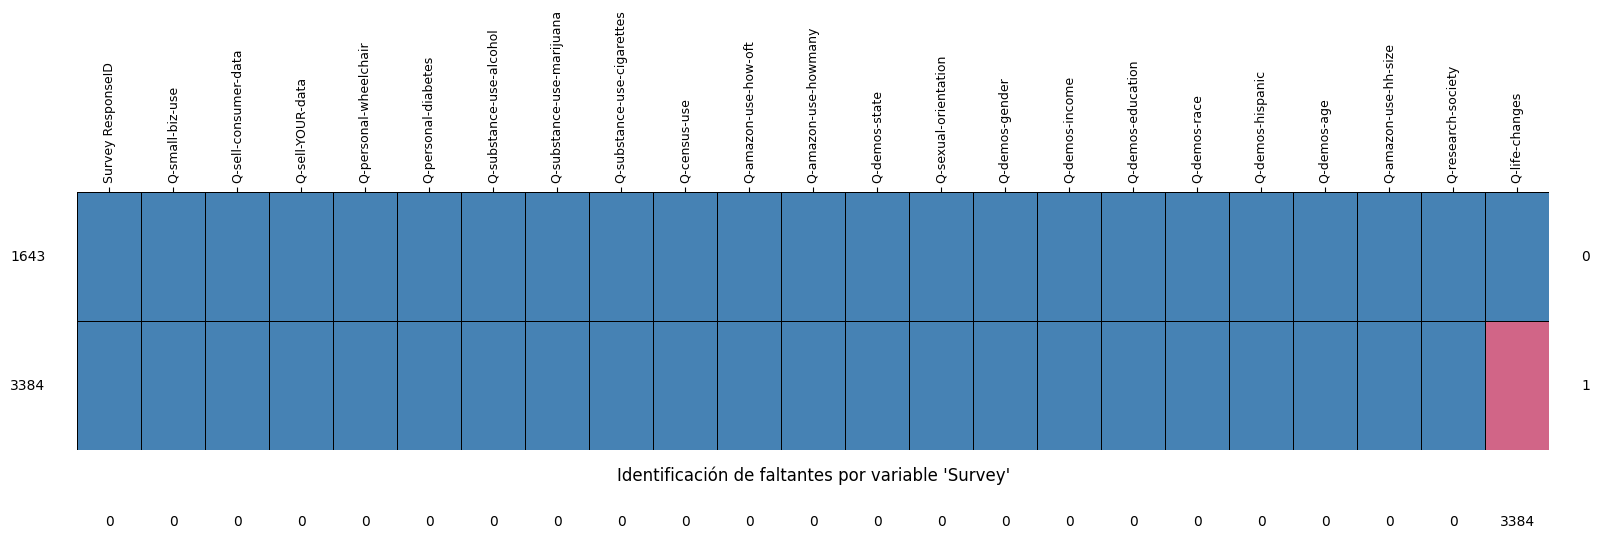

In [195]:
grafico_faltantes_original(
    survey,
    "Identificación de faltantes por variable 'Survey'",
    "figura_2.png",
    figsize=(16, 6)
)

Solo el 32.6% de los encuestados quisieron compartir su experiencia de vida en la encuesta por lo que se considera que el 64% de las personas no quisieron compartir esos datos por tal motivo se elimina la columna

In [196]:
survey.drop(columns=["Q-life-changes"], inplace=True)
survey.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

## Identificacion de duplicados

In [197]:
survey.duplicated().sum()

0

## Deteccion de atipicos

In [198]:
purchases_samsung[["Purchase Price Per Unit", "Quantity"]].describe()

,Purchase Price Per Unit,Quantity
count,19129.000000,19129.000000
mean,31.596865,1.036385
std,88.171687,0.251374
min,0.010000,1.000000
25%,8.990000,1.000000
50%,12.660000,1.000000
75%,19.990000,1.000000
max,1862.870000,10.000000


In [199]:
df_completo = pd.merge(purchases_samsung, survey, left_on="Survey ResponseID", right_on="Survey ResponseID", how="inner")
print(df_completo.shape)
df_completo.info(show_counts=True)

(19129, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19129 entries, 0 to 19128
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Order Date                  19129 non-null  datetime64[ns]
 1   Purchase Price Per Unit     19129 non-null  float64       
 2   Quantity                    19129 non-null  float64       
 3   Shipping Address State      19129 non-null  object        
 4   Title                       19129 non-null  object        
 5   ASIN/ISBN (Product Code)    19129 non-null  object        
 6   Category                    19129 non-null  object        
 7   Survey ResponseID           19129 non-null  object        
 8   amount                      19129 non-null  float64       
 9   Q-demos-age                 19129 non-null  object        
 10  Q-demos-hispanic            19129 non-null  object        
 11  Q-demos-race                19129 non-null

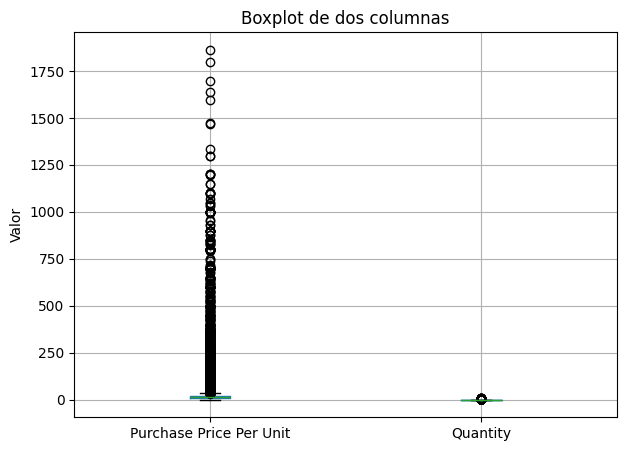

In [200]:

cols = ["Purchase Price Per Unit", "Quantity"]

purchases_samsung[cols].boxplot(figsize=(7, 5))
plt.title("Boxplot de dos columnas")
plt.ylabel("Valor")
plt.show()

In [201]:
purchases_samsung.loc[purchases_samsung["Survey ResponseID"]=="R_2QKhcChxM8s25SS",]

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,amount
613370,2018-04-09,13.99,1.0,MA,Spigen Ultra Hybrid Designed for Samsung Galax...,B0789STF2Y,WIRELESS_ACCESSORY,R_2QKhcChxM8s25SS,13.99
613378,2018-04-26,7.85,1.0,MA,ILLUMI AquaShield Screen Protector Compatible ...,B0754LW8ZJ,SCREEN_PROTECTOR,R_2QKhcChxM8s25SS,7.85
613388,2018-06-01,11.98,1.0,MA,TORRAS Slim Fit Designed for Samsung Galaxy S9...,B079DQBM8W,CELLULAR_PHONE_CASE,R_2QKhcChxM8s25SS,11.98
613550,2019-11-08,17.99,1.0,MA,USB C to HDMI Cable for Home Office 3ft 4K@60H...,B07CL2RHX5,ELECTRONIC_CABLE,R_2QKhcChxM8s25SS,17.99
613592,2019-12-12,13.99,1.0,MA,TOYOUTHS Leather Strap Compatible with Samsung...,B07X44LCNF,WIRELESS_ACCESSORY,R_2QKhcChxM8s25SS,13.99
613608,2019-12-19,17.99,1.0,MA,Glebo Leather Band Compatible with Samsung Gal...,B0821DMM6K,WATCH_BAND,R_2QKhcChxM8s25SS,17.99
613690,2020-02-28,29.98,1.0,MA,6 in 1 Charger Station Compatible with iPhone/...,B07YC65VYY,CHARGING_ADAPTER,R_2QKhcChxM8s25SS,29.98
613772,2020-06-02,15.99,1.0,MA,"BYEASY USB Hub, USB 3.1 C to USB 3.0 Hub with ...",B07TVH9NHP,MULTIPORT_HUB,R_2QKhcChxM8s25SS,15.99
613801,2020-08-10,17.99,1.0,MA,USB C to HDMI Cable for Home Office 3ft 4K@60H...,B07CL2RHX5,ELECTRONIC_CABLE,R_2QKhcChxM8s25SS,17.99
613823,2020-09-10,17.99,1.0,MA,USB C to HDMI Cable for Home Office 3ft 4K@60H...,B07CL2RHX5,ELECTRONIC_CABLE,R_2QKhcChxM8s25SS,17.99


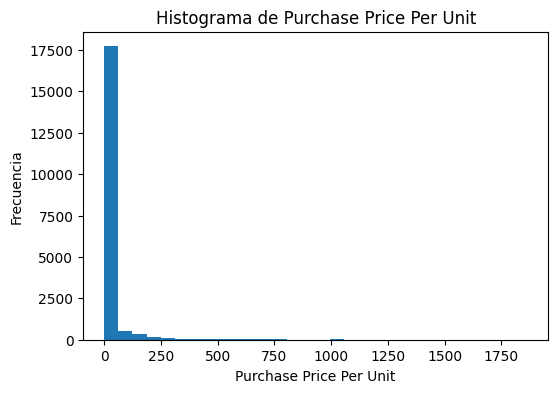

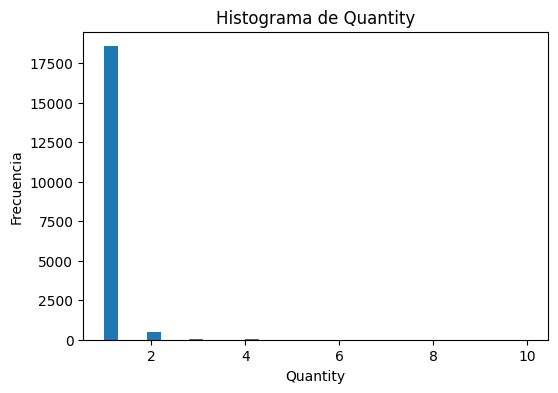

In [202]:
cols = ["Purchase Price Per Unit", "Quantity"]

for col in cols:
    plt.figure(figsize=(6, 4))
    plt.hist(purchases_samsung[col].dropna(), bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

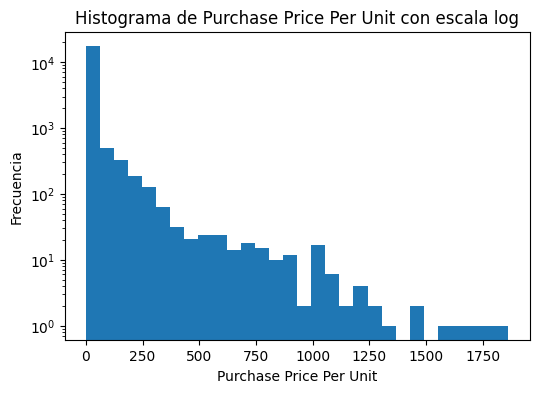

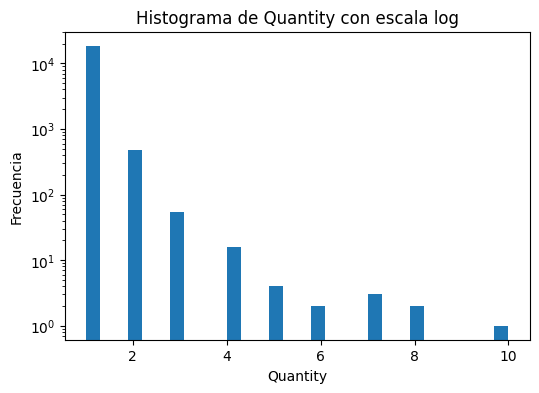

In [203]:
for col in ["Purchase Price Per Unit", "Quantity"]:
    plt.figure(figsize=(6, 4))
    plt.hist(purchases_samsung[col].dropna(), bins=30)
    plt.yscale("log")
    plt.title(f"Histograma de {col} con escala log")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

## Comentario sobre segmentacion de clientes

- Para que la segmentación tenga utilidad práctica, se debe poder cruzar los grupos hallados con los resultados del modelo de billetera (SoW y SioW). Si los IDs en su agrupación no coinciden exactamente con los de las matrices V y W del modelo original, la comparación pierde todo sentido estadístico porque estaría analizando poblaciones distintas.  
- El diseño experimental utiliza dos horizontes temporales no traslapados: T1 (ventana de características, 2018-2021) y T2 (ventana de respuesta/evaluación, 2021-2023).
- T2 se reserva exclusivamente para validar cómo se comportaron esos grupos en el futuro. Agrupar usando datos de T2 para caracterizar segmentos de T1 causaría un error de anacronismo o fuga de información (data leakage), invalidando cualquier conclusión sobre la capacidad del modelo para identificar perfiles de consumo antes de que ocurra la compra.

## Base de datos para k means

In [204]:
# Se crea columna amount como gasto total para crear el rfm
purchases_samsung["amount"] = purchases_samsung["Purchase Price Per Unit"] * purchases_samsung["Quantity"]

## Eliminar amounts > 5000 Regla de Exclusión de “Compradores Severos”

In [205]:
purchases_samsung=purchases_samsung[purchases_samsung["amount"]< 5000]
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19128 entries, 5 to 1850564
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order Date                19128 non-null  datetime64[ns]
 1   Purchase Price Per Unit   19128 non-null  float64       
 2   Quantity                  19128 non-null  float64       
 3   Shipping Address State    19128 non-null  object        
 4   Title                     19128 non-null  object        
 5   ASIN/ISBN (Product Code)  19128 non-null  object        
 6   Category                  19128 non-null  object        
 7   Survey ResponseID         19128 non-null  object        
 8   amount                    19128 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 1.5+ MB


In [206]:
# Filtrar primero la ventana T1
T1_START = pd.to_datetime("2018-01-01")
T1_END   = pd.to_datetime("2021-10-31")

purchases_T1 = purchases_samsung[
    (purchases_samsung["Order Date"] >= T1_START) &
    (purchases_samsung["Order Date"] <= T1_END) &
    (purchases_samsung["amount"] > 0)
].copy()

purchases_T1.shape

(13301, 9)

In [207]:
base_kmeans = (
    purchases_T1
    .groupby("Survey ResponseID")
    .agg(
        recency_days=("Order Date", lambda x: (T1_END - x.max()).days),
        frequency=("Order Date", "count"),
        monetary=("amount", "sum"),
        avg_ticket=("amount", "mean"),
        total_units=("Quantity", "sum"),
        n_categories=("Category", "nunique"),
        n_products=("Title", "nunique")
    )
    .reset_index()
)

base_kmeans.head()

,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
0,R_01vNIayewjIIKMF,248,9,270.91,30.101111,9.0,4,5
1,R_037XK72IZBJyF69,146,5,57.45,11.490000,5.0,3,5
2,R_03aEbghUILs9NxD,23,1,10.99,10.990000,1.0,1,1
3,R_06RZP9pS7kONINr,159,2,63.94,31.970000,2.0,2,2
4,R_06d9ULxrBmkwSTn,215,7,159.46,22.780000,7.0,6,7


In [208]:
base_kmeans.shape

(3067, 8)

## Comentario paso train_ids

Los train_ids sirven para quedarte solamente con los clientes que pertenecen al conjunto de entrenamiento.
La exportación de estos IDs permite reutilizar exactamente la misma partición train/test en otros análisis posteriores, como la segmentación de clientes.
Esto es importante porque garantiza comparabilidad metodológica entre el modelo
Pogit y los modelos de agrupamiento: los clústeres se construyen usando solo
clientes de entrenamiento y luego pueden evaluarse sobre clientes de testeo,
respetando la misma división de datos y evitando fuga de información.

In [209]:
train_ids = pd.read_csv("train_ids.csv")["response_id"].astype(str)

base_train = base_kmeans[
    base_kmeans["Survey ResponseID"].isin(train_ids)
].copy()
print(base_train.shape)
base_train.head()


(1846, 8)


,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
0,R_01vNIayewjIIKMF,248,9,270.91,30.101111,9.0,4,5
1,R_037XK72IZBJyF69,146,5,57.45,11.490000,5.0,3,5
2,R_03aEbghUILs9NxD,23,1,10.99,10.990000,1.0,1,1
4,R_06d9ULxrBmkwSTn,215,7,159.46,22.780000,7.0,6,7
5,R_08uYA7fb4unHGkF,48,1,293.00,293.000000,1.0,1,1


## k -means

### Analisis de correlacion

In [210]:
cols_kmeans = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_ticket",
    "total_units",
    "n_categories",
    "n_products"
]

corr = base_kmeans[cols_kmeans].corr(method="spearman")
corr

,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
recency_days,1.000000,-0.489718,-0.364222,-0.079060,-0.483255,-0.469462,-0.490262
frequency,-0.489718,1.000000,0.786108,0.218391,0.993752,0.934358,0.989716
monetary,-0.364222,0.786108,1.000000,0.732926,0.787449,0.774646,0.782466
avg_ticket,-0.079060,0.218391,0.732926,1.000000,0.230822,0.277560,0.222533
total_units,-0.483255,0.993752,0.787449,0.230822,1.000000,0.928766,0.982905
n_categories,-0.469462,0.934358,0.774646,0.277560,0.928766,1.000000,0.945466
n_products,-0.490262,0.989716,0.782466,0.222533,0.982905,0.945466,1.000000


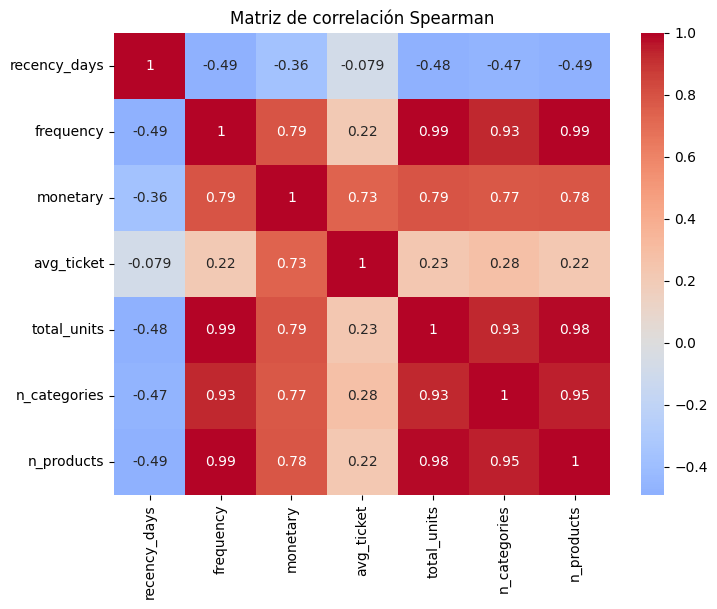

In [211]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación Spearman")
plt.show()

### Comentario

Solo nos quedamos con el rfm porque: 
1. Alta multicolinealidad / Redundancia

frequency, total_units, n_categories y n_products tienen correlaciones extremadamente altas (0.93 a 0.99).
Esto significa que están midiendo casi lo mismo.
monetary también está muy correlacionada con ellas (0.77–0.79).

Mantener todas estas variables hace que el modelo (especialmente K-Medoids + Gower) dé mucho peso artificial a la dimensión “cantidad de compras”, distorsionando los clusters.

Problemas de mantener todas las variables

Aumenta el ruido en la distancia Gower.
Hace los clusters menos interpretables.
Puede crear clusters dominados por “clientes que compran mucho volumen” en vez de perfiles de comportamiento reales.
En algoritmos basados en distancias (como K-Medoids), las variables altamente correlacionadas dominan la solución.

In [212]:
class TukeyWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, k=3):
        self.k = k
        self.caps_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1

        self.caps_ = q3 + self.k * iqr
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X.clip(upper=self.caps_, axis=1)

### Pipeline

In [213]:
# Seleccionar variables RFM para clustering
X = base_train[["recency_days", "frequency", "monetary"]]

# Crear pipeline de preprocesamiento y K-means
pipeline_kmeans = Pipeline([
    ("winsor", TukeyWinsorizer(k=3)),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42, n_init=20))
])

# Entrenar el pipeline completo
pipeline_kmeans.fit(X)

# Extraer las etiquetas de cluster asignadas a cada cliente
labels_kmeans = pipeline_kmeans.named_steps["kmeans"].labels_

### Comentario sobre atipicos

In [214]:
# Transformar X usando winsor + log + scaler
X_transformed = pipeline_kmeans[:-1].transform(X)

# Crear DataFrame con las variables transformadas
df_3d = pd.DataFrame(
    X_transformed,
    columns=["recency_scaled", "frequency_scaled", "monetary_scaled"]
)

# Agregar etiquetas de cluster
df_3d["cluster"] = labels_kmeans.astype(str)

# Gráfico 3D interactivo
fig = px.scatter_3d(
    df_3d,
    x="recency_scaled",
    y="frequency_scaled",
    z="monetary_scaled",
    color="cluster",
    title="Clusters K-means en 3D con variables RFM",
    labels={
        "recency_scaled": "Recency transformada",
        "frequency_scaled": "Frequency transformada",
        "monetary_scaled": "Monetary transformada",
        "cluster": "Cluster"
    },
    opacity=0.7
)

fig.update_traces(marker=dict(size=4))
fig.show()

In [215]:
df_3d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   recency_scaled    1846 non-null   float64
 1   frequency_scaled  1846 non-null   float64
 2   monetary_scaled   1846 non-null   float64
 3   cluster           1846 non-null   object 
dtypes: float64(3), object(1)
memory usage: 57.8+ KB


In [216]:
# Usar los datos ya transformados: winsor + log + scaler
X_transformed = pipeline_kmeans[:-1].transform(X)

resultados = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_transformed)

    resultados.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_transformed, labels),
        "calinski_harabasz": calinski_harabasz_score(X_transformed, labels),
        "davies_bouldin": davies_bouldin_score(X_transformed, labels)
    })

df_indices = pd.DataFrame(resultados)
df_indices

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,2938.873309,0.395833,1630.830552,0.972579
1,3,2306.648648,0.304331,1290.921236,1.162766
2,4,1819.091711,0.326126,1255.247152,1.001246
3,5,1551.593818,0.292421,1182.494318,1.074310
4,6,1374.222623,0.294635,1115.016006,1.044748
5,7,1228.621812,0.294876,1075.051711,1.065944
6,8,1108.822921,0.288638,1048.837764,1.036251
7,9,1017.000981,0.286715,1020.789413,1.074673
8,10,933.143679,0.284231,1006.710830,0.992398


- menor inertia = clusters más compactos.
- Silhouette: mayor es mejor.
- Calinski-Harabasz: mayor es mejor.
- Davies-Bouldin: menor es mejor.

### Resultado k-means


In [217]:
# Crear dataframe con labels de K-means
kmeans_clustered = base_train.copy()
kmeans_clustered["cluster_kmeans"] = labels_kmeans

# Resumen estadístico por cluster usando variables originales
cluster_summary = (
    kmeans_clustered
    .groupby("cluster_kmeans")
    .agg(
        recency_mean=("recency_days", "mean"),
        recency_median=("recency_days", "median"),
        frequency_mean=("frequency", "mean"),
        frequency_median=("frequency", "median"),
        monetary_mean=("monetary", "mean"),
        monetary_median=("monetary", "median"),
        count=("Survey ResponseID", "count")
    )
    .reset_index()
)

# Porcentaje de clientes por cluster
cluster_summary["pct_customers"] = (
    cluster_summary["count"] / len(kmeans_clustered) * 100
).round(2)

display(cluster_summary)

,cluster_kmeans,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,count,pct_customers
0,0,96.746154,67.5,12.610256,10.5,463.124410,301.185,390,21.13
1,1,553.181818,483.5,1.597643,1.0,23.930000,20.240,594,32.18
2,2,49.548507,43.5,3.649254,3.0,67.290448,51.955,268,14.52
3,3,385.205387,308.5,4.398990,4.0,173.154125,104.385,594,32.18


| Clúster | Perfil sugerido | Características principales | Tamaño |
|---:|---|---|---:|
| 0 | Clientes leales de alto valor | Alta frecuencia, mayor gasto, compra relativamente reciente | 21.13% |
| 1 | Clientes inactivos de bajo valor | Muy baja frecuencia, muy bajo gasto, alta recencia | 32.18% |
| 2 | Clientes recientes con potencial | Más recientes, gasto bajo/moderado, frecuencia media-baja | 14.52% |
| 3 | Clientes intermedios | Gasto medio, frecuencia media, menor actualidad | 32.18% |

El modelo K-means con cuatro clústeres permitió identificar segmentos diferenciados de clientes a partir de las variables RFM construidas sobre la ventana T1. El clúster 0 agrupa clientes de alto valor, caracterizados por mayor frecuencia de compra y mayor gasto monetario promedio. El clúster 1 representa clientes inactivos o de bajo valor, con baja frecuencia, bajo gasto y una alta recencia, indicando mayor tiempo desde la última compra. El clúster 2 corresponde a clientes recientes con potencial de desarrollo, dado que presentan la menor recencia, aunque con niveles de gasto y frecuencia todavía moderados. Finalmente, el clúster 3 reúne clientes de comportamiento intermedio, con gasto y frecuencia superiores al grupo inactivo, pero con menor actualidad en la compra. En conjunto, estos resultados muestran que la segmentación permite distinguir clientes leales, clientes recientes con potencial, clientes intermedios y clientes con riesgo de abandono.

## K medoids

In [218]:
# Tus columnas categóricas
ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"
]

nominal_cols = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

cat_cols = ordinal_cols + nominal_cols

# Dejar solo columnas que existan
cat_cols = [col for col in cat_cols if col in survey.columns]
ordinal_cols = [col for col in ordinal_cols if col in survey.columns]
nominal_cols = [col for col in nominal_cols if col in survey.columns]

# Unir base transaccional con encuesta
base_clientes = base_kmeans.merge(
    survey[["Survey ResponseID"] + cat_cols],
    on="Survey ResponseID",
    how="left"
)

# Verificar una fila por cliente
print(base_clientes.shape)
print(base_clientes["Survey ResponseID"].nunique())
print(base_clientes["Survey ResponseID"].duplicated().sum())

(3067, 22)
3067
0


Eliminamos las columnas Q-demos-state y Q-demos-race porque:
- Q-demos-state (51 categorías)
Razones principales para eliminarla:

Alta cardinalidad: Tiene 51 categorías únicas (50 estados + Puerto Rico). En un dataset de solo 1.846 registros, esto genera muy poca densidad por categoría (muchos estados tendrán menos de 30-40 observaciones).
Distorsiona la distancia de Gower: Como Gower trata las variables categóricas por "matching", dos personas de estados diferentes siempre tendrán distancia máxima (1) en esta variable. Esto hace que la variable tenga un peso desproporcionado en la distancia total.
Riesgo de clusters geográficos artificiales: El algoritmo puede terminar agrupando principalmente por estado en lugar de por comportamiento real (recency, frequency, monetary, edad, educación, etc.).
Poco valor predictivo/segmentador para la mayoría de los objetivos de clustering de clientes. La información geográfica a nivel estado es demasiado granular y ruidosa.
- Q-demos-race (Variable multirespuesta)
Razones principales para eliminarla:

Es una variable multirespuesta (una persona puede seleccionar varias razas/etnias). Esto significa que no es una variable categórica simple, sino que probablemente está codificada como múltiples columnas o como texto separado por comas.
Problemas técnicos con Gower: La distancia de Gower está diseñada para variables categóricas simples (una sola categoría por fila). Las variables multirespuesta violan este supuesto y generan distancias inconsistentes o erróneas.
Alta complejidad y ruido: Este tipo de variables suele crear patrones difíciles de interpretar y pueden generar clusters basados en combinaciones raras de razas en lugar de comportamientos reales.

In [219]:
train_ids = pd.read_csv("train_ids.csv")["response_id"].astype(str)

columnas = ['Survey ResponseID', 'recency_days', 'frequency', 'monetary',
       'Q-amazon-use-how-oft', 'Q-demos-age', 'Q-demos-education',
       'Q-demos-income', 'Q-amazon-use-howmany', 'Q-amazon-use-hh-size',
       'Q-demos-hispanic', 'Q-demos-gender', 'Q-sexual-orientation',
       'Q-substance-use-cigarettes', 'Q-substance-use-marijuana',
       'Q-substance-use-alcohol', 'Q-personal-diabetes',
       'Q-personal-wheelchair']

base_train_mixed = base_clientes[
    base_clientes["Survey ResponseID"].isin(train_ids)
].copy()

base_train_mixed = base_train_mixed[columnas]

print(base_train_mixed.shape)
print(base_train_mixed["Survey ResponseID"].nunique())
print(base_train_mixed["Survey ResponseID"].duplicated().sum())

(1846, 18)
1846
0


In [220]:
base_train_mixed.head()

,Survey ResponseID,recency_days,frequency,monetary,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,Q-demos-hispanic,Q-demos-gender,Q-sexual-orientation,Q-substance-use-cigarettes,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair
0,R_01vNIayewjIIKMF,248,9,270.91,Less than 5 times per month,35 - 44 years,Bachelor's degree,"$25,000 - $49,999",1 (just me!),1 (just me!),Yes,Male,heterosexual (straight),No,No,No,No,No
1,R_037XK72IZBJyF69,146,5,57.45,Less than 5 times per month,55 - 64 years,Bachelor's degree,"$25,000 - $49,999",1 (just me!),2,No,Female,heterosexual (straight),No,No,Yes,No,No
2,R_03aEbghUILs9NxD,23,1,10.99,Less than 5 times per month,35 - 44 years,Bachelor's degree,"$50,000 - $74,999",1 (just me!),4+,No,Male,LGBTQ+,No,No,No,No,No
4,R_06d9ULxrBmkwSTn,215,7,159.46,Less than 5 times per month,45 - 54 years,Bachelor's degree,"$100,000 - $149,999",1 (just me!),3,No,Male,heterosexual (straight),No,No,No,No,No
5,R_08uYA7fb4unHGkF,48,1,293.00,5 - 10 times per month,25 - 34 years,High school diploma or GED,"$25,000 - $49,999",1 (just me!),1 (just me!),No,Male,heterosexual (straight),No,No,No,No,No


In [221]:
base_train_mixed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1846 entries, 0 to 3066
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Survey ResponseID           1846 non-null   object 
 1   recency_days                1846 non-null   int64  
 2   frequency                   1846 non-null   int64  
 3   monetary                    1846 non-null   float64
 4   Q-amazon-use-how-oft        1846 non-null   object 
 5   Q-demos-age                 1846 non-null   object 
 6   Q-demos-education           1846 non-null   object 
 7   Q-demos-income              1846 non-null   object 
 8   Q-amazon-use-howmany        1846 non-null   object 
 9   Q-amazon-use-hh-size        1846 non-null   object 
 10  Q-demos-hispanic            1846 non-null   object 
 11  Q-demos-gender              1846 non-null   object 
 12  Q-sexual-orientation        1846 non-null   object 
 13  Q-substance-use-cigarettes  1846 non-n

### Ordinal encoding

In [222]:
df = base_train_mixed.copy()

ordinal_mappings = {
    "Q-demos-education": {
        "Some high school or less": 0,
        "High school diploma or GED": 1,
        "Bachelor's degree": 2,
        "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)": 3,
        "Prefer not to say": np.nan
    },

    "Q-demos-income": {
        "Less than $25,000": 0,
        "$25,000 - $49,999": 1,
        "$50,000 - $74,999": 2,
        "$75,000 - $99,999": 3,
        "$100,000 - $149,999": 4,
        "$150,000 or more": 5,
        "Prefer not to say": np.nan
    },

    "Q-amazon-use-how-oft": {
        "Less than 5 times per month": 0,
        "5 - 10 times per month": 1,
        "More than 10 times per month": 2
    },

    "Q-amazon-use-howmany": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    },

    "Q-demos-age": {
        "18 - 24 years": 0,
        "25 - 34 years": 1,
        "35 - 44 years": 2,
        "45 - 54 years": 3,
        "55 - 64 years": 4,
        "65 and older": 5
    },

    "Q-amazon-use-hh-size": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    }
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"Convertida ordinal: {col}")

Convertida ordinal: Q-demos-education
Convertida ordinal: Q-demos-income
Convertida ordinal: Q-amazon-use-how-oft
Convertida ordinal: Q-amazon-use-howmany
Convertida ordinal: Q-demos-age
Convertida ordinal: Q-amazon-use-hh-size


### Pipeline 

In [223]:
class GowerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_features):
        self.cat_features = cat_features

    def fit(self, X, y=None):
        self.X_train_ = pd.DataFrame(X).copy()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        D = gower.gower_matrix(
            X,
            self.X_train_,
            cat_features=self.cat_features
        )

        return D

In [224]:
numeric_columns = [
    "recency_days",
    "frequency",
    "monetary",
    
]

ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"]

nominal_columns = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

numeric_transformation = Pipeline([
    ("winsor", TukeyWinsorizer(k=3)),
    ("log", FunctionTransformer(np.log1p, validate=False)),
])

ordinal_transformation = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformation, numeric_columns),
        ("ordinal", ordinal_transformation, ordinal_cols),
        ("nominal", "passthrough", nominal_columns)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

cat_features = [False] * len(numeric_columns) + [False] * len(ordinal_cols) + [True] * len(nominal_columns)

pipeline_kmedoids = Pipeline([
    ("preprocessor", preprocessor),
    ("gower", GowerTransformer(cat_features)),
    ("kmedoids", KMedoids(
        n_clusters=4,
        metric="precomputed",
        method="pam",
        init="k-medoids++",
        random_state=123
    ))
])

pipeline_kmedoids.fit(df)

,steps,"[('preprocessor', ...), ('gower', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### Metricas

In [ ]:
resultados_kmedoids = []

for k in range(2, 11):
    
    pipeline_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("gower", GowerTransformer(cat_features)),
        ("kmedoids", KMedoids(
            n_clusters=k,
            metric="precomputed",
            method="pam",
            init="k-medoids++",
            random_state=123
        ))
    ])
    
    pipeline_temp.fit(df)
    
    labels_temp = pipeline_temp.named_steps["kmedoids"].labels_
    
    X_preprocessed_temp = pipeline_temp.named_steps["preprocessor"].transform(df)
    D_gower_temp = pipeline_temp.named_steps["gower"].transform(X_preprocessed_temp)
    
    silhouette_temp = silhouette_score(
        D_gower_temp,
        labels_temp,
        metric="precomputed"
    )
    
    inertia_temp = pipeline_temp.named_steps["kmedoids"].inertia_
    
    resultados_kmedoids.append({
        "k": k,
        "silhouette": silhouette_temp,
        "inertia": inertia_temp
    })

resultados_kmedoids = pd.DataFrame(resultados_kmedoids)

display(resultados_kmedoids)

## HDBSCAN

In [ ]:
class GowerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_features):
        self.cat_features = cat_features

    def fit(self, X, y=None):
        self.X_train_ = pd.DataFrame(X).copy()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        D = gower.gower_matrix(
            X,
            self.X_train_,
            cat_features=self.cat_features
        )

        # HDBSCAN necesita float64 cuando usa metric="precomputed"
        D = D.astype(np.float64)

        return D

In [ ]:
pipeline_hdbscan = Pipeline([
    ("preprocessor", preprocessor),
    ("gower", GowerTransformer(cat_features)),
    ("hdbscan", hdbscan.HDBSCAN(
        min_cluster_size=5,
        metric="precomputed"
    ))
])

pipeline_hdbscan.fit(df)

,steps,"[('preprocessor', ...), ('gower', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [ ]:
labels_hdbscan = pipeline_hdbscan.named_steps["hdbscan"].labels_

In [ ]:
# Preprocesar datos
X_prep = preprocessor.fit_transform(df)

# Calcular distancia Gower
D_gower = gower.gower_matrix(
    pd.DataFrame(X_prep),
    cat_features=cat_features
).astype(np.float64)

print(D_gower.shape)
print(D_gower.dtype)

(1846, 1846)
float64


In [ ]:
resultados_hdbscan = []

min_cluster_sizes = [5, 10, 15, 20, 30, 40, 50, 75, 100]
min_samples_values = [3, 5, 10, 15, 20, 30]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:

        modelo = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="precomputed",
            cluster_selection_method="eom"
        )

        labels = modelo.fit_predict(D_gower)

        # Número de clusters sin contar ruido (-1)
        clusters_validos = set(labels) - {-1}
        n_clusters = len(clusters_validos)

        # Porcentaje de ruido
        ruido_pct = np.mean(labels == -1) * 100

        # Silhouette solo si hay al menos 2 clusters válidos
        if n_clusters >= 2:
            mask = labels != -1

            # También se necesita que queden al menos 2 clusters después de quitar ruido
            labels_sin_ruido = labels[mask]
            D_sin_ruido = D_gower[np.ix_(mask, mask)]

            if len(set(labels_sin_ruido)) >= 2:
                sil = silhouette_score(
                    D_sin_ruido,
                    labels_sin_ruido,
                    metric="precomputed"
                )
            else:
                sil = np.nan
        else:
            sil = np.nan

        # Tamaños de clusters sin ruido
        conteo_clusters = pd.Series(labels[labels != -1]).value_counts()

        if len(conteo_clusters) > 0:
            cluster_min_size = conteo_clusters.min()
            cluster_max_size = conteo_clusters.max()
        else:
            cluster_min_size = 0
            cluster_max_size = 0

        resultados_hdbscan.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "ruido_pct": ruido_pct,
            "silhouette": sil,
            "cluster_min_size": cluster_min_size,
            "cluster_max_size": cluster_max_size
        })

resultados_hdbscan = pd.DataFrame(resultados_hdbscan)

resultados_hdbscan.sort_values(
    by=["silhouette", "ruido_pct"],
    ascending=[False, True]
).head(20)

,min_cluster_size,min_samples,n_clusters,ruido_pct,silhouette,cluster_min_size,cluster_max_size
5,5,30,2,98.808234,0.513751,5,17
21,20,15,2,95.774648,0.440136,29,49
3,5,15,4,94.745395,0.397999,14,49
9,10,15,4,94.745395,0.397999,14,49
15,15,15,3,94.745395,0.376922,19,49
4,5,20,3,97.291441,0.362587,8,31
2,5,10,4,91.386782,0.356388,27,70
8,10,10,4,91.386782,0.356388,27,70
14,15,10,4,91.386782,0.356388,27,70
20,20,10,4,91.386782,0.356388,27,70


Cuidado: el silhouette puede engañar

Cuando calculas silhouette excluyendo el ruido, el valor puede salir alto porque se está calculando solo sobre unos pocos clientes muy bien separados.

Por eso esta combinación:

silhouette = 0.5137
ruido_pct = 98.8%

no debería elegirse como mejor modelo.

Para segmentación comercial, no te sirve un modelo que deje casi todos los clientes como ruido.

Tus resultados indican que HDBSCAN está encontrando pequeños grupos densos, pero no está logrando segmentar bien a la mayoría de clientes.

En otras palabras:

HDBSCAN detecta algunos perfiles muy compactos, pero clasifica una proporción muy alta de observaciones como ruido, por lo que puede no ser el método principal más adecuado para segmentación general de clientes.

## K prototypes

In [ ]:
numeric_columns = [
    "recency_days",
    "frequency",
    "monetary",
    
]

ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"]

nominal_columns = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

numeric_transformation = Pipeline([
    ("winsor", TukeyWinsorizer(k=3)),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

ordinal_transformation = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformation, numeric_columns),
        ("ordinal", ordinal_transformation, ordinal_cols),
        ("nominal", "passthrough", nominal_columns)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


pipeline_kprototypes = Pipeline([
    ("preprocessor", preprocessor),
    ("kprototypes", KPrototypes(
        n_clusters=4,
        init="Huang",
        random_state=123
    ))
])

cat_idx = list(
    range(
        len(numeric_columns) + len(ordinal_cols),
        len(numeric_columns) + len(ordinal_cols) + len(nominal_columns)
    )
)

pipeline_kprototypes.fit(
    df,
    kprototypes__categorical=cat_idx
)

KeyboardInterrupt: 

In [ ]:
clusters = pipeline_kprototypes.named_steps["kprototypes"].labels_
df.head()

,Survey ResponseID,recency_days,frequency,monetary,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,Q-demos-hispanic,Q-demos-gender,Q-sexual-orientation,Q-substance-use-cigarettes,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair
0,R_01vNIayewjIIKMF,248,9,270.91,0,2,2.0,1.0,0,0,Yes,Male,heterosexual (straight),No,No,No,No,No
1,R_037XK72IZBJyF69,146,5,57.45,0,4,2.0,1.0,0,1,No,Female,heterosexual (straight),No,No,Yes,No,No
2,R_03aEbghUILs9NxD,23,1,10.99,0,2,2.0,2.0,0,3,No,Male,LGBTQ+,No,No,No,No,No
4,R_06d9ULxrBmkwSTn,215,7,159.46,0,3,2.0,4.0,0,2,No,Male,heterosexual (straight),No,No,No,No,No
5,R_08uYA7fb4unHGkF,48,1,293.00,1,1,1.0,1.0,0,0,No,Male,heterosexual (straight),No,No,No,No,No


## Dendograma con gower

In [ ]:
cat_features = [False] * len(numeric_columns) + [False] * len(ordinal_cols) + [True] * len(nominal_columns)
pipeline_jerarquico = Pipeline([
    ("preprocessor", preprocessor),
    ("gower", GowerTransformer(cat_features)),
    ("jerarquico", AgglomerativeClustering(
        n_clusters=3,
        metric="precomputed",
        linkage="average"
    ))
])

pipeline_jerarquico.fit(df)

,steps,"[('preprocessor', ...), ('gower', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [ ]:
resultados = []

X_pre = preprocessor.fit_transform(df)
D_gower = GowerTransformer(cat_features).fit_transform(X_pre)

for linkage in ["average", "complete", "single"]:
    for k in range(2, 8):
        modelo = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage=linkage
        )
        
        labels = modelo.fit_predict(D_gower)
        
        conteo = pd.Series(labels).value_counts().sort_index()
        
        silhouette = silhouette_score(
            D_gower,
            labels,
            metric="precomputed"
        )
        
        resultados.append({
            "linkage": linkage,
            "k": k,
            "silhouette_gower": silhouette,
            "min_cluster": conteo.min(),
            "max_cluster": conteo.max(),
            "n_clusters_reales": conteo.shape[0],
            "distribucion": conteo.to_dict()
        })

tabla_distribuciones = pd.DataFrame(resultados)

tabla_distribuciones.sort_values(
    by="silhouette_gower",
    ascending=False
)

,linkage,k,silhouette_gower,min_cluster,max_cluster,n_clusters_reales,distribucion
0,average,2,0.334050,5,1841,2,"{0: 1841, 1: 5}"
12,single,2,0.323514,3,1843,2,"{0: 1843, 1: 3}"
1,average,3,0.280926,3,1838,3,"{0: 1838, 1: 5, 2: 3}"
13,single,3,0.274354,1,1842,3,"{0: 3, 1: 1842, 2: 1}"
2,average,4,0.236118,3,1815,4,"{0: 1815, 1: 23, 2: 3, 3: 5}"
3,average,5,0.207209,3,1790,5,"{0: 25, 1: 1790, 2: 3, 3: 5, 4: 23}"
4,average,6,0.178928,2,1790,6,"{0: 1790, 1: 23, 2: 3, 3: 5, 4: 23, 5: 2}"
14,single,4,0.164023,1,1842,4,"{0: 1842, 1: 2, 2: 1, 3: 1}"
6,complete,2,0.154894,477,1369,2,"{0: 1369, 1: 477}"
15,single,5,0.130447,1,1841,5,"{0: 1841, 1: 2, 2: 1, 3: 1, 4: 1}"
